# Acoustic Uroflowmetry Prototype
Estimate urinary flow rate from sound using DSP features and super vised ML models to estimate new measures.

Pipeline:
1. Calibration from known flows
2. Feature extraction (MFCC + spectral features) with Digital Signal Processing
3. RMS-based segmentation
4. KNN similarity to estimate flow per segment
5. Plot uroflow curve


In [124]:
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

import operator

from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# from sklearn.ensemble import RandomForestClassifier

import glob
import os

from scipy.signal import butter, lfilter




## Feature Extraction

In [125]:
def extract_features_old(y, sr):
    features = []

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    features.extend(np.mean(mfcc, axis=1))

    spec_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features.append(np.mean(spec_centroid))

    spec_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features.append(np.mean(spec_bandwidth))

    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    features.append(np.mean(rolloff))

    zcr = librosa.feature.zero_crossing_rate(y)
    features.append(np.mean(zcr))

    rms = librosa.feature.rms(y=y)
    features.append(np.mean(rms))


        
    return np.array(features)


In [126]:
def extract_features(y, sr):

    # -------------------------
    # 0️⃣ Pré-traitement robuste micro
    # -------------------------
    
    # Enlève les très basses fréquences (bruits de pièce)
    # y = librosa.effects.preemphasis(y)

    # =========================
    # 1️⃣ MFCC (texture globale)
    # =========================
    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=13,
        n_fft=2048,
        hop_length=512
    )

    # Normalisation cepstrale (CMVN) : stabilise les MFCC entre micros
    # mfcc = (mfcc - np.mean(mfcc, axis=1, keepdims=True)) / \
    #        (np.std(mfcc, axis=1, keepdims=True) + 1e-8)

    # mfcc = mfcc - np.mean(mfcc, axis=1, keepdims=True)

    features = []
    features.extend(np.mean(mfcc, axis=1))
    features.extend(np.std(mfcc, axis=1))

    # =========================
    # 2️⃣ Features spectrales
    # =========================
    spec_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features.append(np.mean(spec_centroid))
    features.append(np.std(spec_centroid))

    spec_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features.append(np.mean(spec_bandwidth))
    features.append(np.std(spec_bandwidth))

    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)
    features.append(np.mean(rolloff))
    features.append(np.std(rolloff))

    # =========================
    # 3️⃣ Bruit vs tonal
    # =========================
    spec_flatness = librosa.feature.spectral_flatness(y=y)
    features.append(np.mean(spec_flatness))
    features.append(np.std(spec_flatness))

    # =========================
    # 4️⃣ Dynamique / énergie
    # =========================
    rms = librosa.feature.rms(y=y)
    features.append(np.mean(rms))
    features.append(np.std(rms))

    # =========================
    # 5️⃣ Rugosité temporelle
    # =========================
    zcr = librosa.feature.zero_crossing_rate(y)
    features.append(np.mean(zcr))
    features.append(np.std(zcr))

    # =========================
    # 6️⃣ Flux spectral (variation du spectre dans le temps)
    # Très corrélé aux turbulences et donc au débit
    # Plus le flux est élevé, plus le jet est turbulent / intense
    # =========================
    # Calcul du spectrogramme magnitude
    S = np.abs(librosa.stft(y, n_fft=2048, hop_length=512))
    # Flux spectral : différence entre frames successives
    flux = np.sqrt(np.sum(np.diff(S, axis=1)**2, axis=0)) / S.shape[0]
    features.append(np.mean(flux))
    features.append(np.std(flux))

    return np.array(features)


In [127]:
def extract_features_old(y, sr):
    '''
    BUT : Extraire de l’information physique mesurable (features) à partir du signal sonore brut
    
    Un jet d’urine qui frappe l’eau :

    crée des bulles
    crée des micro-turbulences
    génère un bruit proche d’un bruit blanc filtré

    Il n’y a pas de fréquence fondamentale stable.'''


    # TODO: pensez à mettre dns les sons étalons des silences débit = 0 (3 bruits blancs minimum)
    
    features = []

    # =========================
    # 1️⃣ MFCC (texture globale)
    # =========================
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    features.extend(np.mean(mfcc, axis=1))
    features.extend(np.std(mfcc, axis=1))  # variabilité temporelle

    # =========================
    # 2️⃣ Features spectrales (bruit)
    # =========================
    spec_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features.append(np.mean(spec_centroid))
    features.append(np.std(spec_centroid))

    spec_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features.append(np.mean(spec_bandwidth))
    features.append(np.std(spec_bandwidth))

    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)
    features.append(np.mean(rolloff))
    features.append(np.std(rolloff))

    # =========================
    # 3️⃣ Flatness (bruit vs tonal)
    # =========================
    spec_flatness = librosa.feature.spectral_flatness(y=y)
    features.append(np.mean(spec_flatness))
    features.append(np.std(spec_flatness))

    # =========================
    # 4️⃣ Dynamique / énergie
    # =========================
    rms = librosa.feature.rms(y=y)
    features.append(np.mean(rms))
    features.append(np.std(rms))

    # =========================
    # 5️⃣ Rugosité temporelle
    # =========================
    zcr = librosa.feature.zero_crossing_rate(y)
    features.append(np.mean(zcr))
    features.append(np.std(zcr))

    return np.array(features)


## RMS-based Segmentation

In [128]:
def segment_audio(y, sr, frame_duration=0.2, threshold=0.01):
    
    frame_length = int(frame_duration * sr)
    rms = librosa.feature.rms(y=y, frame_length=frame_length)[0]

    segments = []
    start = None

    for i, val in enumerate(rms):
        if val > threshold and start is None:
            start = i
        elif val <= threshold and start is not None:
            end = i
            segments.append((start, end))
            start = None

    return segments, frame_length


## Build Calibration Dataset

In [129]:
def build_calibration_dataset(folder='calibration_sounds'):
    '''Visualisation des fréquences '''
    rows = []
    # ⚠️ IMPORTANT : définir les noms de colonnes
    feature_names = [
        # ---- MFCC (13 x mean)
        "mfcc1_mean","mfcc2_mean","mfcc3_mean","mfcc4_mean","mfcc5_mean",
        "mfcc6_mean","mfcc7_mean","mfcc8_mean","mfcc9_mean","mfcc10_mean",
        "mfcc11_mean","mfcc12_mean","mfcc13_mean",
    
        # ---- MFCC (13 x std)
        "mfcc1_std","mfcc2_std","mfcc3_std","mfcc4_std","mfcc5_std",
        "mfcc6_std","mfcc7_std","mfcc8_std","mfcc9_std","mfcc10_std",
        "mfcc11_std","mfcc12_std","mfcc13_std",
    
        # ---- Spectral centroid
        "spec_centroid_mean","spec_centroid_std",
    
        # ---- Spectral bandwidth
        "spec_band_mean","spec_band_std",
    
        # ---- Spectral rolloff
        "spec_rolloff_mean","spec_rolloff_std",
    
        # ---- Spectral flatness
        "spec_flat_mean","spec_flat_std",
        
        # ---- RMS
        "rms_mean","rms_std",

        # ---- Zero Crossing Rate
        "zero_cross_rate_mean","zero_cross_rate_std",

        # ---- Flux spectral
        "flux_mean","flux_std",
    
        # ---- Target
        "debit"
    ]

    files = glob.glob(os.path.join(folder, "*.wav"))

    files_sorted = sorted(
        files,
        key=lambda x: float(os.path.basename(x).split("_")[0])
    )
    # files_sorted = sorted(files)

    for file in files_sorted:
        
        # debit = float(os.path.basename(file).split('_')[0].replace('mls.wav',''))
        debit = float(os.path.basename(file).partition('_')[0])

                
        print(debit)
        y, sr = librosa.load(file, sr=32000)
        
        # Visualisation des fréquences
        S = np.abs(librosa.stft(y))
        freqs = librosa.fft_frequencies(sr=sr)

        # moyenne temporelle
        mean_spectrum = np.mean(S, axis=1)

        # plt.plot(freqs, mean_spectrum)
        # plt.xlabel("Fréquence (Hz)")
        # plt.ylabel("Amplitude")
        # plt.show()

        # fin graphique
        
        feat = extract_features(y, sr)
        rows.append(np.append(feat, debit))

    

    df = pd.DataFrame(rows,columns=feature_names)
    # df = pd.DataFrame(rows)
    df.to_csv('calibration_features.csv', index=False)
    print('Calibration dataset saved.')

    


In [130]:
def preprocess_audio(
    file,                     # chemin du fichier audio
    sr=32000,                 # fréquence cible après resampling
    lowcut=150,               # fréquence minimale utile pour le flux liquide
    highcut=8000,             # fréquence maximale utile
    filter_order=4,           # ordre du filtre passe-bande
    target_rms=0.1,           # niveau RMS cible (stabilise les micros)
    compression_strength=0.7, # compression dynamique (réduit écarts entre appareils)
    trim_signal=False,         # active ou non la suppression du silence début/fin
    trim_padding=1.0,         # durée conservée avant/après le flux détecté (secondes)
    max_internal_silence=2.0  # silence max autorisé au milieu d'un flux (secondes)
):
    """
    Prétraitement complet pour analyse acoustique du débit urinaire.
    """

    # ---------------------------------------------------------
    # 1) Chargement + mono + resampling
    # ---------------------------------------------------------
    y, sr = librosa.load(file, sr=sr, mono=True)

    # ---------------------------------------------------------
    # 2) Réduction du bruit ambiant (spectral gating)
    # ---------------------------------------------------------
    stft = librosa.stft(y)
    magnitude, phase = librosa.magphase(stft)

    noise_profile = np.mean(magnitude[:, :20], axis=1, keepdims=True)
    reduction_factor = 1.5
    cleaned_mag = np.maximum(magnitude - reduction_factor * noise_profile, 0)

    y = librosa.istft(cleaned_mag * phase)

    # ---------------------------------------------------------
    # 3) Suppression silence début / fin (optionnelle)
    # avec gestion des pauses internes
    # ---------------------------------------------------------
    if trim_signal:

        rms = librosa.feature.rms(y=y)[0]
        threshold = np.percentile(rms, 65)

        frame_length = int(len(y) / len(rms))
        frame_time = frame_length / sr

        active = rms > threshold
        active_idx = np.where(active)[0]

        if len(active_idx) > 0:

            segments = []
            start = active_idx[0]

            for i in range(1, len(active_idx)):
                gap = active_idx[i] - active_idx[i-1]

                silence_duration = gap * frame_time

                if silence_duration > max_internal_silence:
                    segments.append((start, active_idx[i-1]))
                    start = active_idx[i]

            segments.append((start, active_idx[-1]))

            global_start = segments[0][0]
            global_end = segments[-1][1]

            start_sample = max(0, int(global_start * frame_length - trim_padding * sr))
            end_sample = min(len(y), int(global_end * frame_length + trim_padding * sr))

            y = y[start_sample:end_sample]

    # ---------------------------------------------------------
    # 4) Suppression offset DC
    # ---------------------------------------------------------
    y = y - np.mean(y)

    # ---------------------------------------------------------
    # 5) Normalisation RMS
    # ---------------------------------------------------------
    rms = np.sqrt(np.mean(y**2) + 1e-9)
    y = y * (target_rms / rms)

    # ---------------------------------------------------------
    # 6) Filtre turbulence liquide
    # ---------------------------------------------------------
    nyq = 0.5 * sr
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(filter_order, [low, high], btype="band")
    y = lfilter(b, a, y)

    # ---------------------------------------------------------
    # 7) Compression dynamique
    # ---------------------------------------------------------
    y = np.sign(y) * (np.abs(y) ** compression_strength)

    # ---------------------------------------------------------
    # 8) Normalisation finale: suppression de l'information lié au materiel
    # ---------------------------------------------------------

    '''suppression essentiellement :

            volume global du micro
            distance au micro
            gain automatique
            différences de niveau entre appareils
    '''
    y = librosa.util.normalize(y)

    return y, sr


In [131]:
def build_dataset(folder='calibration_sounds_features', margin_sec=3):
    rows = []

    feature_names = [
        "mfcc1_mean","mfcc2_mean","mfcc3_mean","mfcc4_mean","mfcc5_mean",
        "mfcc6_mean","mfcc7_mean","mfcc8_mean","mfcc9_mean","mfcc10_mean",
        "mfcc11_mean","mfcc12_mean","mfcc13_mean",

        "mfcc1_std","mfcc2_std","mfcc3_std","mfcc4_std","mfcc5_std",
        "mfcc6_std","mfcc7_std","mfcc8_std","mfcc9_std","mfcc10_std",
        "mfcc11_std","mfcc12_std","mfcc13_std",

        "spec_centroid_mean","spec_centroid_std",
        "spec_band_mean","spec_band_std",
        "spec_rolloff_mean","spec_rolloff_std",
        "spec_flat_mean","spec_flat_std",
        "rms_mean","rms_std",
        "zero_cross_rate_mean","zero_cross_rate_std",
        "flux_mean","flux_std",
        "debit"
    ]

    files = glob.glob(os.path.join(folder, "*.wav"))

    files_sorted = sorted(
        files,
        key=lambda x: float(os.path.basename(x).split("_")[0])
    )

    for file in files_sorted:

        debit = float(os.path.basename(file).partition('_')[0])

        # y, sr = librosa.load(file, sr=32000)
        y, sr = preprocess_audio(file, sr=32000, trim_signal=False, trim_padding=margin_sec)


        # --- Normalisation amplitude
        '''suppressons essentiellement :

            le volume global du micro
            la distance au micro
            le gain automatique
            les différences de niveau entre appareils

            Donc on enlève une information qui n’est pas liée au débit réel, mais au matériel.'''
        # y = librosa.util.normalize(y)

        feat = extract_features(y, sr)
        rows.append(np.append(feat, debit))

    df = pd.DataFrame(rows,columns=feature_names)
    df.to_csv(folder + "_features.csv", index=False)
    print(f'Calibration dataset saved as {folder}_features.csv')



In [132]:
def build_test_dataset_old(folder='sons_tests'):
    rows = []
    # ⚠️ IMPORTANT : définir les noms de colonnes
    feature_names = [
        # ---- MFCC (13 x mean)
        "mfcc1_mean","mfcc2_mean","mfcc3_mean","mfcc4_mean","mfcc5_mean",
        "mfcc6_mean","mfcc7_mean","mfcc8_mean","mfcc9_mean","mfcc10_mean",
        "mfcc11_mean","mfcc12_mean","mfcc13_mean",
    
        # ---- MFCC (13 x std)
        "mfcc1_std","mfcc2_std","mfcc3_std","mfcc4_std","mfcc5_std",
        "mfcc6_std","mfcc7_std","mfcc8_std","mfcc9_std","mfcc10_std",
        "mfcc11_std","mfcc12_std","mfcc13_std",
    
        # ---- Spectral centroid
        "spec_centroid_mean","spec_centroid_std",
    
        # ---- Spectral bandwidth
        "spec_band_mean","spec_band_std",
    
        # ---- Spectral rolloff
        "spec_rolloff_mean","spec_rolloff_std",
    
        # ---- Spectral flatness
        "spec_flat_mean","spec_flat_std",
        
        # ---- RMS
        "rms_mean","rms_std",

        # ---- Zero Crossing Rate
        "zero_cross_rate_mean","zero_cross_rate_std",
    
        # ---- Target
        "debit"
    ]

    files = glob.glob(os.path.join(folder, "*.wav"))

    files_sorted = sorted(
        files,
        key=lambda x: float(os.path.basename(x).split("_")[0])
    )
    # files_sorted = sorted(files)

    for file in files_sorted:
        
        # debit = float(os.path.basename(file).split('_')[0].replace('mls.wav',''))
        debit = float(os.path.basename(file).partition('_')[0])

                
        # print(debit)
        y, sr = librosa.load(file, sr=32000)
        
        # Visualisation des fréquences
        S = np.abs(librosa.stft(y))
        freqs = librosa.fft_frequencies(sr=sr)

        # moyenne temporelle
        mean_spectrum = np.mean(S, axis=1)

        # plt.plot(freqs, mean_spectrum)
        # plt.xlabel("Fréquence (Hz)")
        # plt.ylabel("Amplitude")
        # plt.show()

        # fin graphique
        
        feat = extract_features(y, sr)
        rows.append(np.append(feat, debit))

    

  
    df = pd.DataFrame(rows,columns=feature_names)
    df.to_csv(folder + "_features.csv", index=False)
    print(f'Calibration dataset saved as {folder}_features.csv')
    

    


In [133]:

build_dataset('sons_tests')

df_test=pd.read_csv("sons_tests_features.csv", sep=",")

Calibration dataset saved as sons_tests_features.csv


In [134]:
build_dataset('calibration_sounds')

df=pd.read_csv("calibration_sounds_features.csv", sep=",")

Calibration dataset saved as calibration_sounds_features.csv


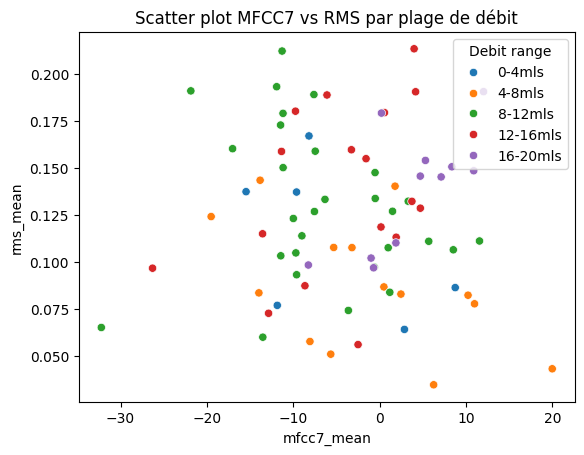

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

# # 1️⃣ Charger les données
df = pd.read_csv("calibration_sounds_features.csv", sep=",")

# 2️⃣ Définir les bornes des plages
bins = [0, 4, 8, 12, 16, 20]
labels = ["0-4mls", "4-8mls", "8-12mls", "12-16mls", "16-20mls"]

# 3️⃣ Créer la nouvelle variable catégorielle
df["debit_range"] = pd.cut(
    df["debit"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# 4️⃣ Créer le nouveau dataframe
df_new = df[["mfcc7_mean", "rms_mean", "debit_range"]]


plt.figure()

sns.scatterplot(
    data=df_new,
    x="mfcc7_mean",
    y="rms_mean",
    hue="debit_range"
)

plt.xlabel("mfcc7_mean")
plt.ylabel("rms_mean")
plt.title("Scatter plot MFCC7 vs RMS par plage de débit")

plt.legend(title="Debit range")
plt.show()



In [136]:
import pandas as pd
import plotly.express as px

# Charger les données
df = pd.read_csv("calibration_sounds_features.csv", sep=",")

# Bornes des plages
bins = [0, 4, 8, 12, 16, 20]
labels = ["0-4mls", "4-8mls", "8-12mls", "12-16mls", "16-20mls"]

# Variable catégorielle
df["debit_range"] = pd.cut(
    df["debit"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Scatter interactif
fig = px.scatter(
    df,
    # x="mfcc7_mean",
    # y="rms_mean",
    x="mfcc12_mean",
    y="mfcc9_mean",
    color="debit_range",
    hover_data={
        "debit": True,
        "mfcc12_mean": True,
        "mfcc9_mean": True
    },
    title="Scatter plot MFCC12 vs MFCC9 par plage de débit"
)

fig.show()


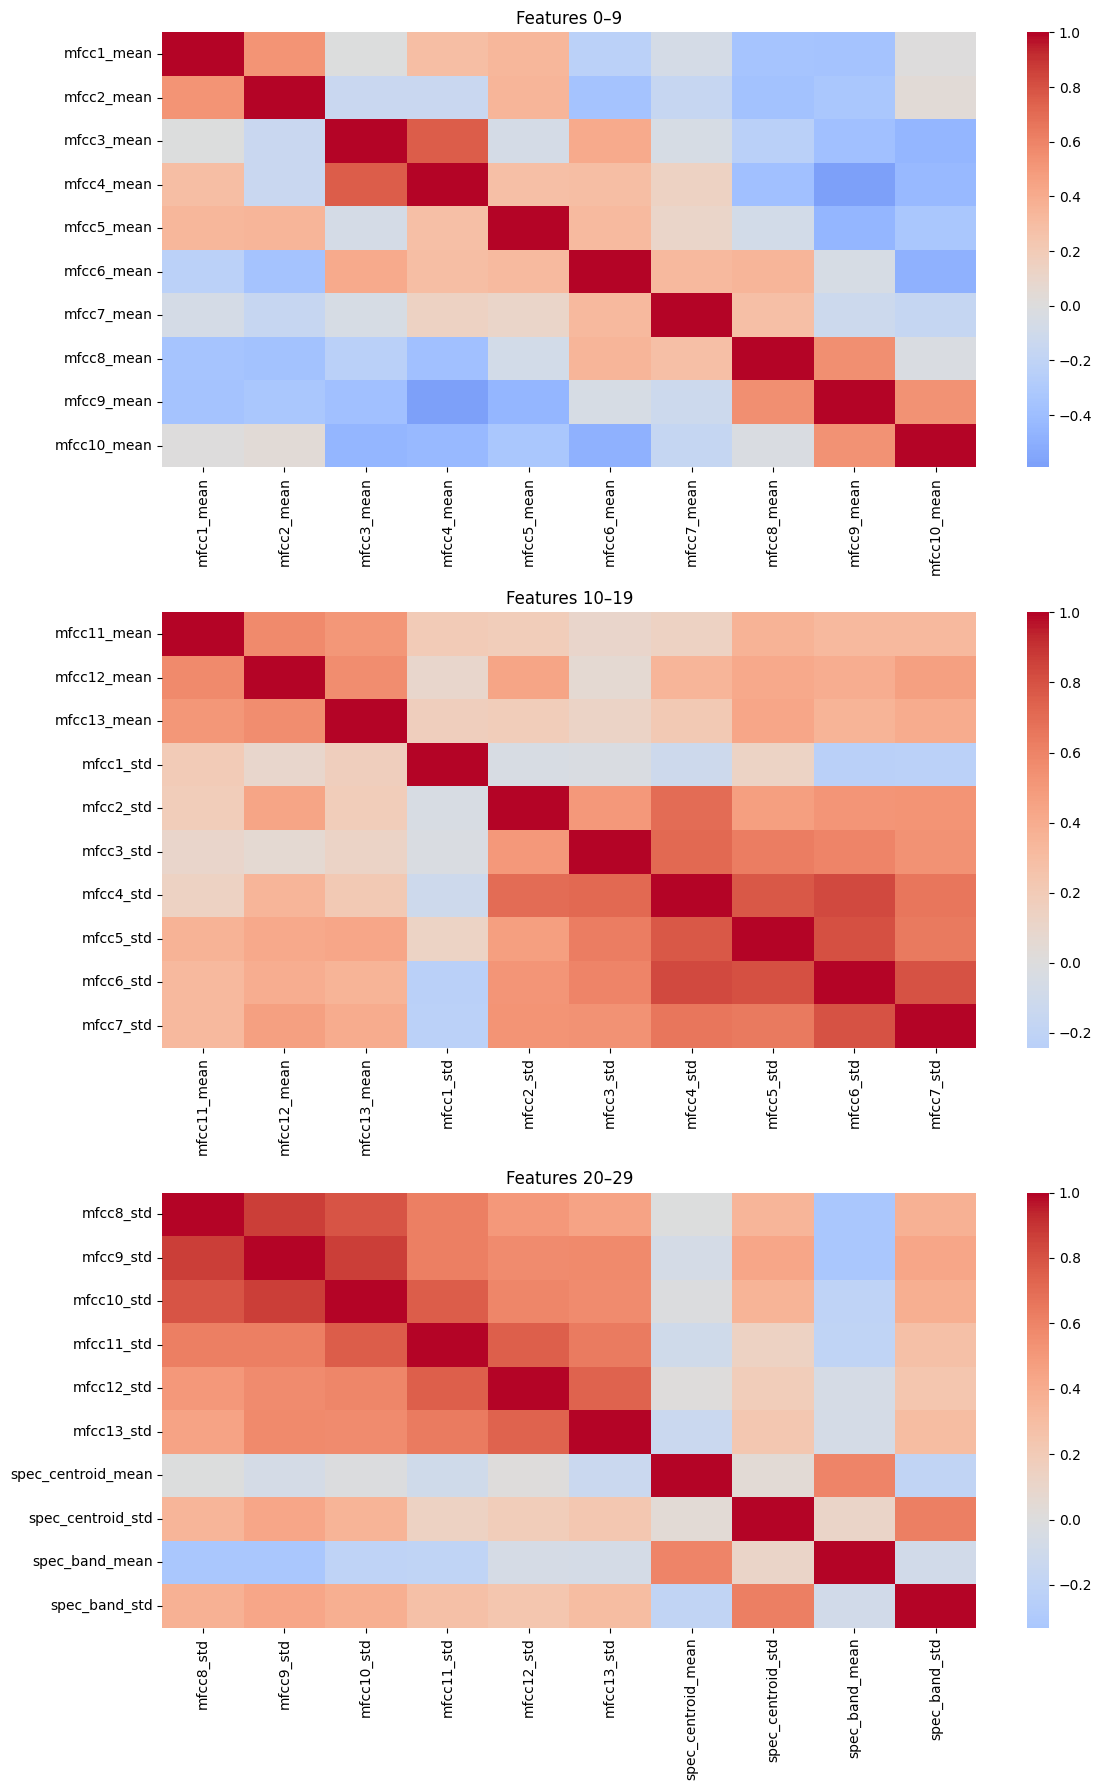

In [137]:
# recherche correlations
import matplotlib.pyplot as plt
import seaborn as sns

# Sélection des blocs
Z1 = df.iloc[:, 0:10]
Z2 = df.iloc[:, 10:20]
Z3 = df.iloc[:, 20:30]

# Création figure avec 3 lignes, 1 colonne
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Heatmap 1
sns.heatmap(Z1.corr(numeric_only=True),
            ax=axes[0],
            cmap="coolwarm",
            center=0)
axes[0].set_title("Features 0–9")

# Heatmap 2
sns.heatmap(Z2.corr(numeric_only=True),
            ax=axes[1],
            cmap="coolwarm",
            center=0)
axes[1].set_title("Features 10–19")

# Heatmap 3
sns.heatmap(Z3.corr(numeric_only=True),
            ax=axes[2],
            cmap="coolwarm",
            center=0)
axes[2].set_title("Features 20–29")

plt.tight_layout()
plt.show()

In [138]:
df[["mfcc7_mean","spec_rolloff_mean", "debit"]].corr()

,mfcc7_mean,spec_rolloff_mean,debit
mfcc7_mean,1.000000,0.006690,0.313004
spec_rolloff_mean,0.006690,1.000000,-0.244936
debit,0.313004,-0.244936,1.000000


In [139]:
from sklearn.linear_model import LinearRegression

X_single = df[["mfcc7_mean"]]
y = df["debit"]

model = LinearRegression()
model.fit(X_single, y)

r2 = model.score(X_single, y)
print("R² avec mfcc7_mean seul :", r2)

R² avec mfcc7_mean seul : 0.09797159981521208


## Load Calibration and Prepare KNN

Préparation jeux de données

In [140]:
calib = pd.read_csv("calibration_sounds_features.csv", sep=",")
# X = features
X = calib.iloc[:, :-1]
# y = débit (target)
y = calib.iloc[:, -1]

jeu_test_real = pd.read_csv("sons_tests_features.csv", sep=",")

X_real = jeu_test_real.iloc[:, :-1]
y_real = jeu_test_real.iloc[:, -1]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [141]:
# model KNN regressor
def load_knn_model(k=3):
    
    # Modèle supervisé
    model = KNeighborsRegressor(
        n_neighbors=k,
        metric='euclidean',
        weights='distance'   # ou'uniform', 'distance' si tu veux pondérer par proximité
    )
    
    model.fit(X_calib, y_calib)

    return model



0.6141664178853539


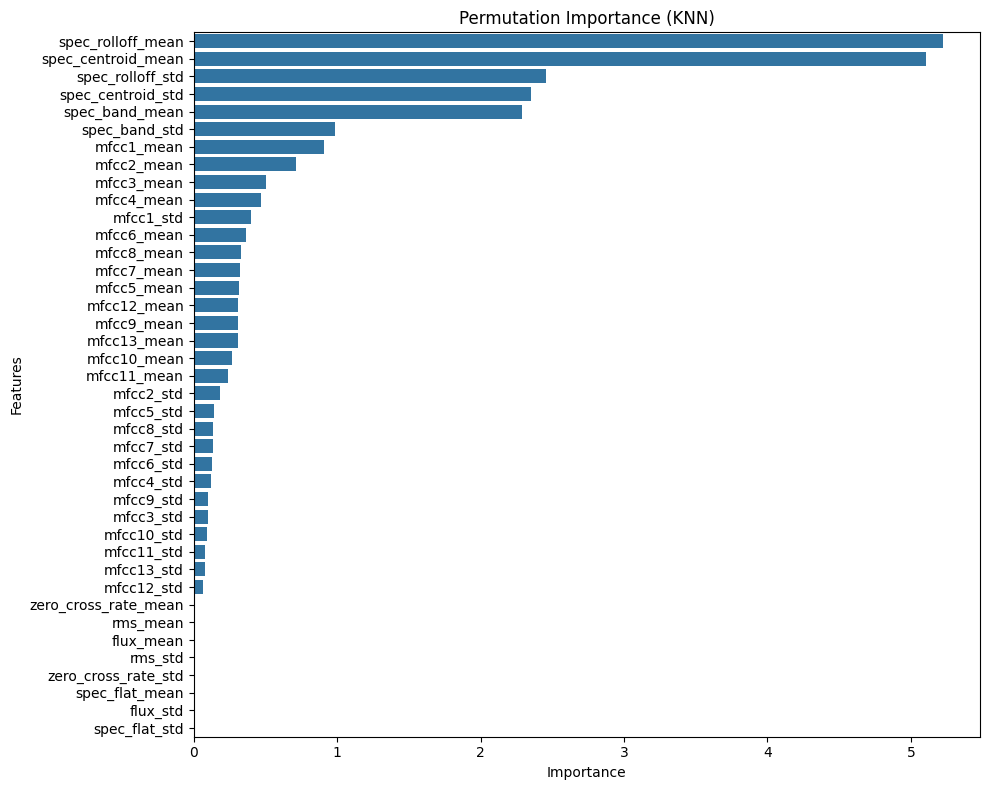

In [142]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

'''Principe :

On mesure la performance du modèle

On mélange une feature

On regarde combien la performance chute

Si elle chute beaucoup → feature importante.'''

# Fit modèle
rf_nn = KNeighborsRegressor(
    n_neighbors=3,
    metric='euclidean',
    weights='distance'
)

test = KNeighborsRegressor(
    n_neighbors=3,
    metric='euclidean',
    weights='distance'
)

rf_nn.fit(X, y)

test.fit(X_train, y_train)

# Permutation importance
result = permutation_importance(
    rf_nn,
    X,
    y,
    n_repeats=20,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

importances = result.importances_mean
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10,8))

sns.barplot(
    x=importances[indices],
    y=calib.columns[:-1][indices]
)
print(test.score(X_test, y_test))
plt.title("Permutation Importance (KNN)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [143]:
from sklearn.metrics import mean_absolute_error

# Prédictions
y_pred = test.predict(X_test)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_test": y_test.values,
    "y_pred": y_pred
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_test"] - comparaison["y_pred"])

print(comparaison)

# MAE
mae = round(mean_absolute_error(y_test, y_pred), 2)
print("MAE:", mae)

    y_test     y_pred    erreur
0   19.120  18.737669  0.382331
1    0.000   4.488213  4.488213
2   18.348  20.519865  2.171865
3    9.030  10.771920  1.741920
4    5.260  10.619473  5.359473
5   13.605  10.182098  3.422902
6    5.000  10.262477  5.262477
7    7.140   8.667971  1.527971
8    3.700  11.142801  7.442801
9   16.528  11.083171  5.444829
10  14.771  11.362003  3.408997
11  15.847  12.482740  3.364260
12  13.333  11.119103  2.213897
13  18.796  18.726843  0.069157
14  15.105  13.486485  1.618515
15  16.051  13.870870  2.180130
16  10.430  15.050937  4.620937
17  20.876  19.286904  1.589096
MAE: 3.13


In [144]:
# Prédictions
y_pred_real = rf_nn.predict(X_real)

# Tableau comparatif
comparaison = pd.DataFrame({
    "y_test": y_real.values,
    "y_pred": y_pred_real
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_test"] - comparaison["y_pred"])

print(comparaison)

# MAE
mae = round(mean_absolute_error(y_real, y_pred_real), 2)
print("MAE:", mae)

   y_test     y_pred    erreur
0   8.930  12.687116  3.757116
1   9.290   9.250543  0.039457
2  10.090  17.307996  7.217996
3  11.049  18.551736  7.502736
4  11.120  10.163045  0.956955
5  11.760  11.538167  0.221833
6  12.500  18.635349  6.135349
7  18.650  14.698364  3.951636
8  21.270  16.477424  4.792576
MAE: 3.84


0.6349379087851356


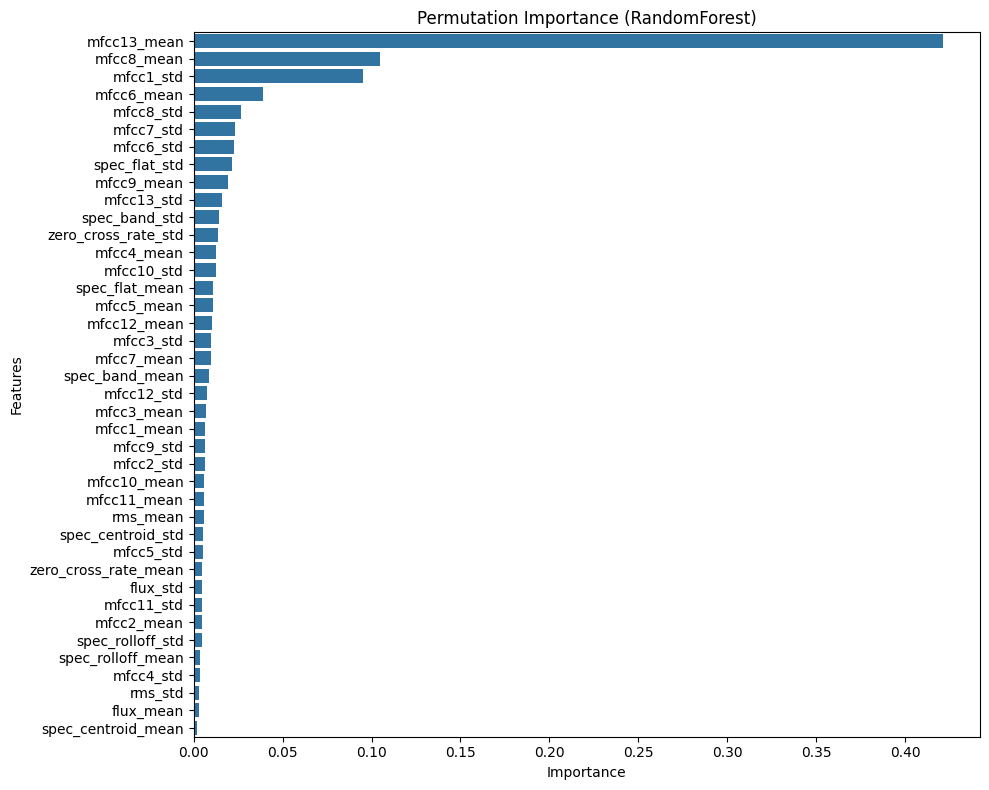

In [145]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

# entrainement tout le set de données
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X, y)

train_model = RandomForestRegressor(random_state=42)
train_model.fit(X_train, y_train)

importances = rf_model.feature_importances_

indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10,8))

sns.barplot(
    x=importances[indices],
    y=calib.columns[:-1][indices]
)
print(train_model.score(X_test, y_test))
plt.title("Permutation Importance (RandomForest)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [146]:
y_test
y_pred = train_model.predict(X_test)
print(y_test)
print(y_pred)
mae=round(mean_absolute_error(y_test, y_pred),2)
print("MAE:", mae)

75    19.120
0      0.000
70    18.348
22     9.030
12     5.260
56    13.605
10     5.000
18     7.140
4      3.700
67    16.528
61    14.771
64    15.847
53    13.333
73    18.796
62    15.105
66    16.051
33    10.430
78    20.876
Name: debit, dtype: float64
[19.1335   9.58034 20.46929 10.2065   6.35285 17.38445  5.44748  7.83799
  4.61536 17.72221 19.72953 19.06737 13.6535  20.08989 12.25652 18.2117
 18.41659 21.3062 ]
MAE: 2.46


In [147]:


# Prédictions
y_pred_real = rf_model.predict(X_real)

# Tableau comparatif
# Tableau comparatif
comparaison = pd.DataFrame({
    "y_test": y_real.values,
    "y_pred": y_pred_real
})

# Ajouter l'erreur absolue
comparaison["erreur"] = abs(comparaison["y_test"] - comparaison["y_pred"])

print(comparaison)

# MAE
mae = round(mean_absolute_error(y_real, y_pred_real), 2)
print("MAE:", mae)

   y_test    y_pred   erreur
0   8.930  12.67794  3.74794
1   9.290   9.72783  0.43783
2  10.090  11.52112  1.43112
3  11.049  12.72387  1.67487
4  11.120   8.60022  2.51978
5  11.760  11.99069  0.23069
6  12.500  12.26682  0.23318
7  18.650  18.49642  0.15358
8  21.270  19.77467  1.49533
MAE: 1.32


R2 test : 0.5959459683156297


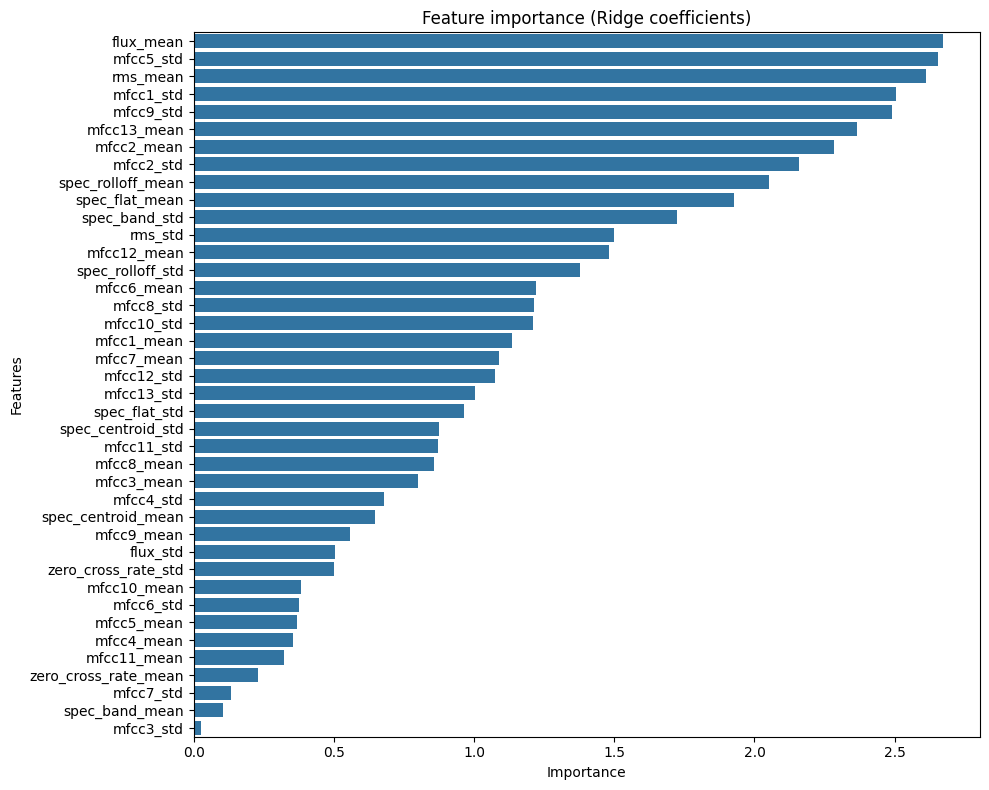

In [148]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scaling (important pour Ridge)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entraînement du modèle
ridge_model = Ridge(random_state=42)
ridge_model.fit(X_train_scaled, y_train)

# Importance = valeur absolue des coefficients
importances = np.abs(ridge_model.coef_)

# Tri
indices = np.argsort(importances)[::-1]

# Score test
score = ridge_model.score(X_test_scaled, y_test)
print("R2 test :", score)

# Plot
plt.figure(figsize=(10,8))
sns.barplot(
    x=importances[indices],
    y=calib.columns[:-1][indices]
)

plt.title("Feature importance (Ridge coefficients)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


/home/ed_st/.pyenv/versions/Artefact/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning:

Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.528e-01, tolerance: 2.392e-01



R2 test : 0.39697269669626056


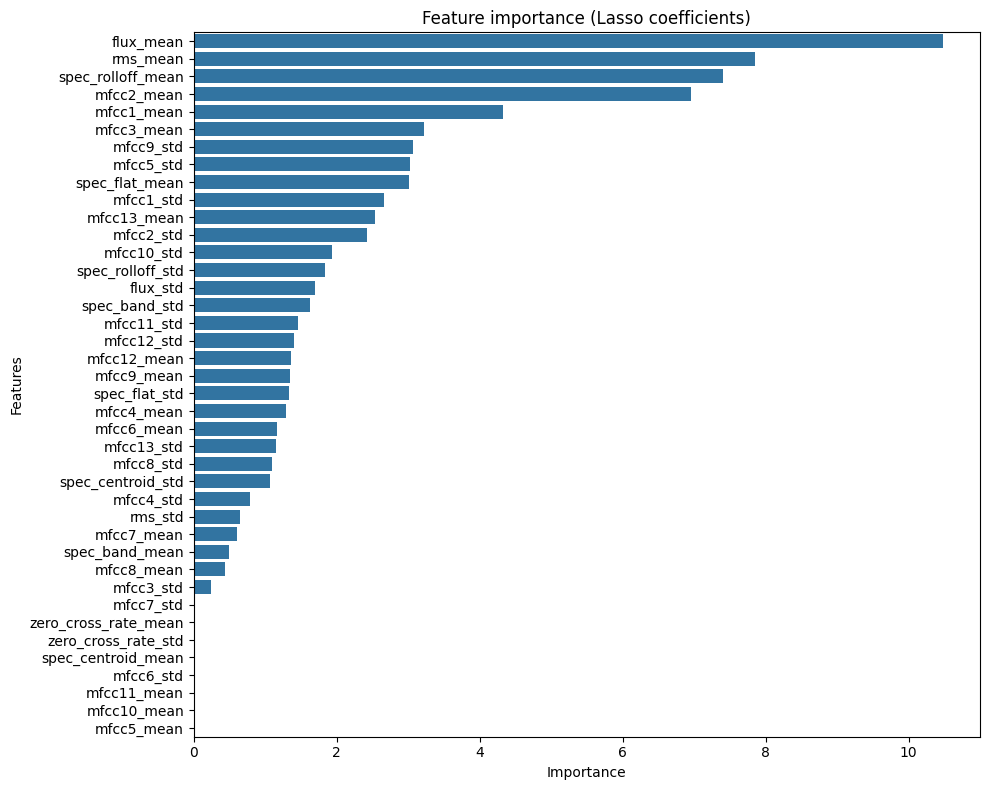

Features retenues par Lasso :
Index(['mfcc1_mean', 'mfcc2_mean', 'mfcc3_mean', 'mfcc4_mean', 'mfcc6_mean',
       'mfcc7_mean', 'mfcc8_mean', 'mfcc9_mean', 'mfcc12_mean', 'mfcc13_mean',
       'mfcc1_std', 'mfcc2_std', 'mfcc3_std', 'mfcc4_std', 'mfcc5_std',
       'mfcc7_std', 'mfcc8_std', 'mfcc9_std', 'mfcc10_std', 'mfcc11_std',
       'mfcc12_std', 'mfcc13_std', 'spec_centroid_std', 'spec_band_mean',
       'spec_band_std', 'spec_rolloff_mean', 'spec_rolloff_std',
       'spec_flat_mean', 'spec_flat_std', 'rms_mean', 'rms_std', 'flux_mean',
       'flux_std'],
      dtype='object')


In [149]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scaling (très important pour Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entraînement du modèle
lasso_model = Lasso(alpha=0.01, random_state=42)
lasso_model.fit(X_train_scaled, y_train)

# Importance = valeur absolue des coefficients
importances = np.abs(lasso_model.coef_)

# Tri
indices = np.argsort(importances)[::-1]

# Score test
score = lasso_model.score(X_test_scaled, y_test)
print("R2 test :", score)

# Plot
plt.figure(figsize=(10,8))
sns.barplot(
    x=importances[indices],
    y=calib.columns[:-1][indices]
)

plt.title("Feature importance (Lasso coefficients)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# Features sélectionnées par Lasso
selected_features = calib.columns[:-1][lasso_model.coef_ != 0]
print("Features retenues par Lasso :")
print(selected_features)


Rappel : qu’est-ce que mfcc7_mean ?

Les MFCC (Mel-Frequency Cepstral Coefficients) décrivent :

la forme du spectre

la structure fréquentielle globale

le “timbre” du signal

mfcc7_mean = moyenne temporelle du 7ᵉ coefficient.

👉 Donc c’est une information spectrale compressée.

Si le débit influence :

    la pression

    la turbulence

    le bruit généré

    la répartition énergétique dans le spectre

Alors il est plausible qu’un MFCC soit corrélé au débit.

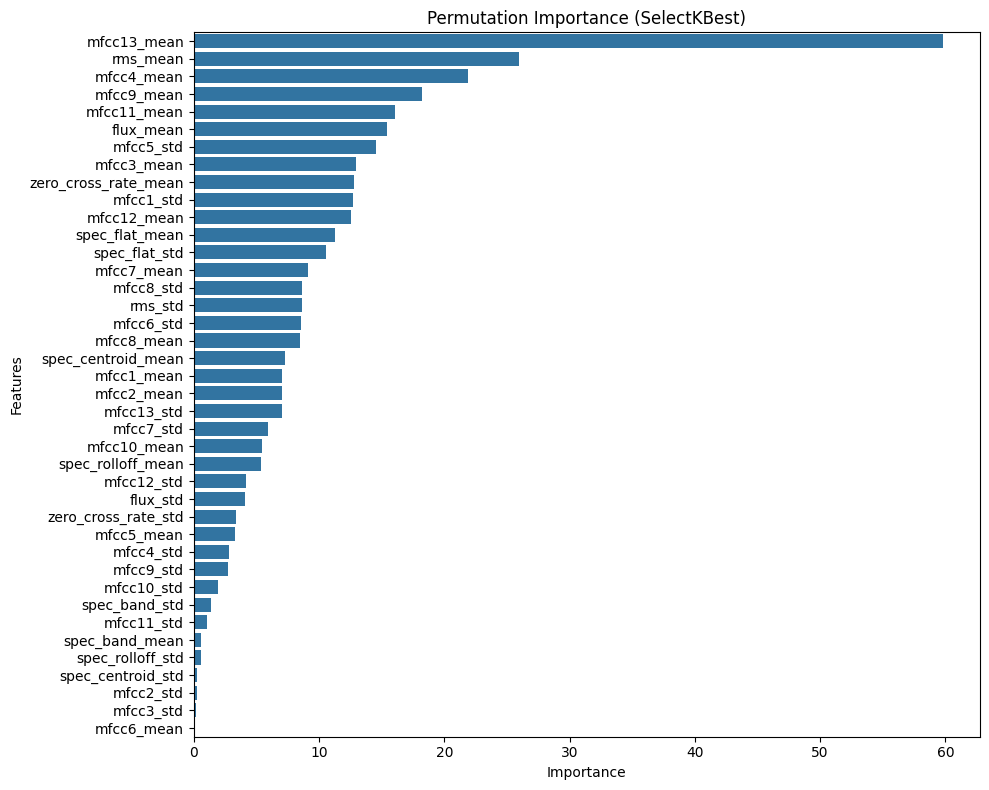

In [150]:
from sklearn.feature_selection import SelectKBest, f_regression

# mesure corrélation linéaire uniquement!!

selector = SelectKBest(score_func=f_regression, k="all")
selector.fit(X, y)


importances = selector.scores_
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10,8))

sns.barplot(
    x=importances[indices],
    y=calib.columns[:-1][indices]
)

plt.title("Permutation Importance (SelectKBest)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## Estimate Flow for a Segment

In [151]:
def estimate_flow(feat, model):
    """
    feat : vecteur features 1D (35 features par ex.)
    model : modèle KNeighborsRegressor déjà entraîné
    """
    
    feat = np.array(feat).reshape(1, -1)  # nécessaire pour sklearn
    prediction = model.predict(feat)

    return prediction[0]


## Analyze a Real Recording

In [152]:
def analyze_recording(file_path, nn, y_calib):
    y, sr = librosa.load(file_path, sr=32000)
    segments, frame_len = segment_audio(y, sr)

    results = []

    for i, (s, e) in enumerate(segments):
        seg = y[s*frame_len:e*frame_len]
        feat = extract_features(seg, sr)
        debit = estimate_flow(feat, nn, y_calib)
        duration = (e - s) * 0.2
        results.append({"phase": i+1, "debit": debit, "duree": duration})

    return results


## Plot Uroflow Curve

In [153]:
def plot_uroflow(results):
    times = []
    flows = []
    t = 0

    for r in results:
        times.append(t)
        flows.append(r['debit'])
        t += r['duree']

    plt.step(times, flows)
    plt.xlabel('Time (s)')
    plt.ylabel('Flow (ml/s)')
    plt.title('Estimated Uroflow Curve')
    plt.show()
